# Paper figures

Reproduces every figure in the manuscript *Automated calculation of stationary
statistics for Itô stochastic differential equations*, one section per figure.
Each section is self-contained: it computes from the shipped models/simulators
and writes `figures/fig<N>_<name>.png` + `.pdf` (the exact files used in the
paper).

Conventions match the paper: white noise normalized as
$\langle\xi(t)\xi(t')\rangle = 2D\,\delta(t-t')$, so the linear
(Ornstein–Uhlenbeck) stationary variance is $C(0)=D/\mu$.

In [1]:
%matplotlib inline
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'api' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'api')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
os.chdir(os.path.join(_root, 'notebooks'))   # cwd=notebooks/ for simulations/ paths
os.makedirs('figures', exist_ok=True)
import daedalus as dd

## Figure 1 — failures of the linear approximation (Section II)

**(a)** Quartic OU process $\partial_t\phi = -\mu\phi - \varepsilon\phi^3 + \xi$
($\mu = D = 1$): the equal-time variance $C(0)$ from direct simulation falls
below the linear approximation $D/\mu$ as $\varepsilon$ grows — a moment-closure
failure the linear/Gaussian ansatz cannot see. The pipeline'''s loop-corrected
curves (dashed, revisited in Section VI) recover it.

**(b)** Mutually exciting 2-neuron alpha-kernel Hawkes process, stationary mean
rate vs. coupling scale $s$ ($w\to s\,w$). The **linear** transfer $\phi=av$
mean is exact (simulation on the self-consistent line). **Caveat for the paper:**
at these shipped parameters the **quadratic** naive closure is *also* accurate
(<1%) throughout the stable regime — the doubly-filtered voltage self-averages,
so Jensen barely bites until the process destabilizes past $s\approx1.3$. This
panel therefore does **not** illustrate a closure failure; a compelling Hawkes
illustration needs a less-filtered regime (delta coupling / fast membrane) or a
statistic that fails earlier (e.g. the closure'''s over-prediction of the
critical coupling). Left here as scaffolding pending that choice.

In [2]:
# ── panel (a): OU quartic, C(0) vs eps ───────────────────────────────────────
from simulations.ou_langevin_sim_numba import sim_ou_quartic_numba

mu, D = float(1.0), float(1.0)
eps_grid = [float(e) for e in (0.0, 0.02, 0.04, 0.06, 0.08, 0.10)]
model, mod = dd.load_model('ou_quartic')

# simulation: stationary variance of finely-binned x (dt_bin << 1/mu)
dt_sim, dt_bin = float(0.01), float(0.02)
T_sim, N_RUNS  = float(2.0e5), int(4)
n_steps        = int(T_sim / dt_sim)
bs             = int(max(round(dt_bin / dt_sim), 1))
n_bins         = int(n_steps // bs)
_ = sim_ou_quartic_numba(int(1000), dt_sim, mu, float(0.05), D, float(0.0),
                         bs, int(100), int(0))               # JIT warmup
sim_C0, sim_err = [], []
t0 = time.perf_counter()
for eps in eps_grid:
    vs = []
    for r in range(N_RUNS):
        xb = sim_ou_quartic_numba(n_steps, dt_sim, mu, eps, D, float(0.0),
                                  bs, n_bins, int(1000 + r))
        vs.append(float(np.var(xb)))
    sim_C0.append(np.mean(vs)); sim_err.append(np.std(vs, ddof=1) / np.sqrt(N_RUNS))
print('OU sims: %.1fs' % (time.perf_counter() - t0))

# pipeline: tree / +1-loop / +2-loop equal-time variance (eps=0 is the free
# model: tree = D/mu exactly, loop corrections vanish — no run needed)
th = {0: [], 1: [], 2: []}
t0 = time.perf_counter()
for eps in eps_grid:
    if eps == 0.0:
        for ell in th: th[ell].append(D / mu)
        continue
    cfg = dd.Config(k=2, max_ell=2, external_fields=[('dx', 1), ('dx', 1)],
                    parameters={'mu': mu, 'eps': eps, 'D': D},
                    tau_grid=(-2.0, 2.0, 5), parallel=False)
    res = dd.run(model, cfg, mod)
    i0 = int(np.argmin(np.abs(np.asarray(res['tau_grid']))))
    run = 0.0
    for ell in (0, 1, 2):
        run += float(np.real(res['C_tau_by_ell'][ell])[i0])
        th[ell].append(run)
print('OU pipeline: %.1fs' % (time.perf_counter() - t0))

OU sims: 10.0s
OU pipeline: 1.8s


In [3]:
# ── panel (b): 2-neuron Hawkes, mean rate vs coupling scale ─────────────────
from simulations.hawkes_sim_multipop_numba import (
    sim_hawkes_multipop_numba, sim_hawkes_multipop_quad_alpha_numba)

hm, _ = dd.load_model('quadratic_hawkes_alpha')
prm  = {p['name']: p['default'] for p in hm['parameters']
        if 'default' in p}                      # saddle params carry no default
a    = np.array(prm['a'], dtype=float)          # transfer gain
Em   = np.array(prm['Em'], dtype=float)         # baseline drive
tauv = np.array(prm['tau'], dtype=float)
taug = np.array(prm['taug'], dtype=float)
W0   = np.array(prm['w'], dtype=float)
A    = np.diag(a)
# stay in the stable regime (quadratic Hawkes runs away past s~1.3)
s_grid = [float(x) for x in (0.0, 0.3, 0.6, 0.9, 1.05, 1.15)]

def rates_linear_exact(s):
    # n = a v,  v = Em + s W n  (int g = 1)  ->  (I - s A W) n = A Em
    return np.linalg.solve(np.eye(2) - s * A @ W0, A @ Em)

def rates_quad_naive(s, iters=400):
    # naive closure <v^2> -> <v>^2:  n_i = a_i (Em_i + s (W n)_i)^2
    n = a * Em**2
    for _ in range(iters):
        n_new = a * (Em + s * W0 @ n)**2
        n = 0.5 * n + 0.5 * n_new
        if not np.all(np.isfinite(n)) or n.max() > 1e6:
            return np.full(2, np.nan)
    return n

def sim_rates(kind, s, seeds=(11, 12, 13)):
    dt, T = float(0.01), float(2.0e5)
    n_steps = int(T / dt); bs = int(25); n_bins = int(n_steps // bs)
    Ws = np.ascontiguousarray(s * W0)
    v0 = Em.copy()
    out = []
    for sd in seeds:
        f = (sim_hawkes_multipop_numba if kind == 'lin'
             else sim_hawkes_multipop_quad_alpha_numba)
        _, _, tot = f(n_steps, dt, tauv, a, Em, Ws, taug, v0,
                      bs, n_bins, int(sd))
        out.append(np.asarray(tot, dtype=float) / T)
    out = np.array(out)                          # (seeds, 2)
    m = out.mean(axis=0).mean()
    if not np.isfinite(m) or m > 1e3:            # runaway guard
        return np.nan, np.nan
    return m, out.mean(axis=1).std(ddof=1) / np.sqrt(len(seeds))

t0 = time.perf_counter()
lin_th  = [rates_linear_exact(s).mean() for s in s_grid]
quad_th = [rates_quad_naive(s).mean() for s in s_grid]
lin_sim,  lin_err  = zip(*[sim_rates('lin', s) for s in s_grid])
quad_sim, quad_err = zip(*[sim_rates('quad', s) for s in s_grid])
print('Hawkes sims: %.1fs' % (time.perf_counter() - t0))

Hawkes sims: 24.8s


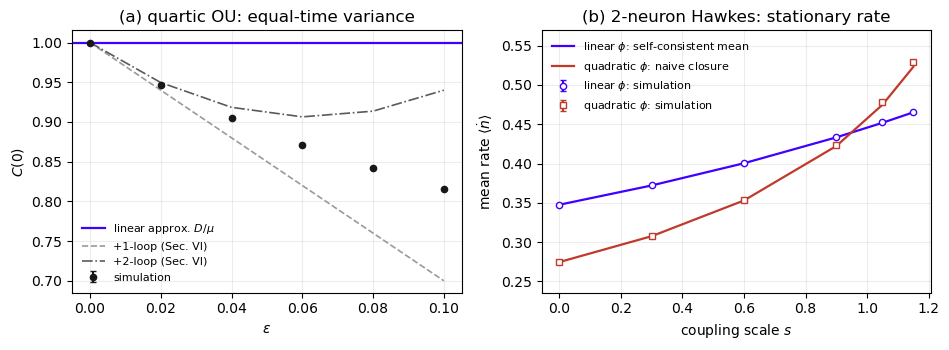

saved figures/fig1_moment_closure.{png,pdf}


In [4]:
# ── assemble Figure 1 ────────────────────────────────────────────────────────
fig, (axa, axb) = plt.subplots(1, 2, figsize=(9.6, 3.6))

axa.axhline(D / mu, color='#3F00FF', lw=1.6, label=r'linear approx. $D/\mu$')
axa.plot(eps_grid, th[1], '--', lw=1.2, color='#9a9a9a', label='+1-loop (Sec. VI)')
axa.plot(eps_grid, th[2], '-.', lw=1.2, color='#5a5a5a', label='+2-loop (Sec. VI)')
axa.errorbar(eps_grid, sim_C0, yerr=sim_err, fmt='o', ms=4.5, color='#181818',
             capsize=2.5, label='simulation', zorder=5)
axa.set_xlabel(r'$\varepsilon$'); axa.set_ylabel(r'$C(0)$')
axa.set_title(r'(a) quartic OU: equal-time variance')
axa.legend(fontsize=8, frameon=False)

axb.plot(s_grid, lin_th, '-', lw=1.6, color='#3F00FF',
         label=r'linear $\phi$: self-consistent mean')
axb.errorbar(s_grid, lin_sim, yerr=lin_err, fmt='o', ms=4.5, color='#3F00FF',
             mfc='white', capsize=2.5, label=r'linear $\phi$: simulation')
axb.plot(s_grid, quad_th, '-', lw=1.6, color='#C0392B',
         label=r'quadratic $\phi$: naive closure')
axb.errorbar(s_grid, quad_sim, yerr=quad_err, fmt='s', ms=4.5, color='#C0392B',
             mfc='white', capsize=2.5, label=r'quadratic $\phi$: simulation')
axb.set_xlabel(r'coupling scale $s$'); axb.set_ylabel(r'mean rate $\langle\dot n\rangle$')
axb.margins(y=0.15)                              # autoscale tight to the data
axb.set_title('(b) 2-neuron Hawkes: stationary rate')
axb.legend(fontsize=8, frameon=False)

for ax in (axa, axb): ax.grid(alpha=0.22)
fig.tight_layout()
fig.savefig('figures/fig1_moment_closure.png', dpi=200, bbox_inches='tight')
fig.savefig('figures/fig1_moment_closure.pdf', bbox_inches='tight')
plt.show()
print('saved figures/fig1_moment_closure.{png,pdf}')